# INTRODUCTION

**Machine Learning is the field of Artificial Intelligence(AI), that enables  a system to learn  patterns from data to make predictions without being explicitly programmed or need much human intervention.**

**Here, Multiple regression is implemented to model a relationship between a dependent variable and multiple independent variables. This model is trained using the normal equation.**

# Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Reading Dataset

In [8]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("behavioral_indicators_internal_marks.csv")
df.shape

Saving behavioral_indicators_internal_marks.csv to behavioral_indicators_internal_marks (1).csv


(96, 14)

# **1). Understanding datasets**
*Performing various operations:*

In [9]:
df.sample(12)
# It gives a random sample of 12 students

,CRN,Theory_Attendance_Pct,Assignment_Unit_I,Assignment_Unit_II,Assignment_Unit_III,Assignment_PU_6_Set,Lab_Attendance_Pct,Lab_Report_1a,Lab_Report_1b,ML_on_Git,Viva_Marks,Final_Theory_Marks_30,Final_Practical_Marks_20,Total_Internal_Marks_50
89,023-390,43.750000,1.0,0.0,0.0,4,71.428571,1.0,1.0,0,0.5,9.920,12.0,21.920
59,023-360,56.250000,1.0,1.0,0.0,4,66.666667,1.0,1.0,4,0.5,15.572,15.5,31.072
23,023-324,94.444444,1.0,0.0,0.0,4,80.000000,1.0,1.0,4,1.0,19.640,13.0,32.640
30,023-331,88.888889,1.0,1.0,0.0,4,100.000000,1.0,1.0,4,1.5,16.320,18.5,34.820
77,023-378,81.250000,1.0,0.0,0.0,4,100.000000,1.0,1.0,4,0.5,11.700,16.5,28.200
55,023-356,0.000000,0.0,0.0,0.0,0,0.000000,0.0,0.0,0,0.0,0.000,0.0,0.000
19,023-320,77.777778,1.0,0.5,0.5,4,100.000000,1.0,1.0,4,1.0,14.660,17.0,31.660
92,023-393,62.500000,1.0,1.0,0.5,4,71.428571,1.0,1.0,0,0.5,14.412,12.0,26.412
82,023-383,81.250000,1.0,1.0,0.0,4,100.000000,1.0,1.0,4,1.0,20.840,19.0,39.840
56,023-357,87.500000,1.0,1.0,0.0,4,66.666667,1.0,0.5,4,1.0,18.060,14.5,32.560


In [10]:
df.info()
# It specifies the numbe of rows and columns,column names, gives noon-null count and the datatype of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CRN                       96 non-null     object 
 1   Theory_Attendance_Pct     96 non-null     float64
 2   Assignment_Unit_I         96 non-null     float64
 3   Assignment_Unit_II        96 non-null     float64
 4   Assignment_Unit_III       96 non-null     float64
 5   Assignment_PU_6_Set       96 non-null     int64  
 6   Lab_Attendance_Pct        96 non-null     float64
 7   Lab_Report_1a             96 non-null     float64
 8   Lab_Report_1b             96 non-null     float64
 9   ML_on_Git                 96 non-null     int64  
 10  Viva_Marks                96 non-null     float64
 11  Final_Theory_Marks_30     96 non-null     float64
 12  Final_Practical_Marks_20  96 non-null     float64
 13  Total_Internal_Marks_50   96 non-null     float64
dtypes: float64(1

## 2). Preprocessing
  **Preprocessing is the process of cleaning, transforming and preparing raw data before training any model.**

In [11]:
#2.1 Converting all column names to lowercase
df.columns = df.columns.str.lower()
df.columns

Index(['crn', 'theory_attendance_pct', 'assignment_unit_i',
       'assignment_unit_ii', 'assignment_unit_iii', 'assignment_pu_6_set',
       'lab_attendance_pct', 'lab_report_1a', 'lab_report_1b', 'ml_on_git',
       'viva_marks', 'final_theory_marks_30', 'final_practical_marks_20',
       'total_internal_marks_50'],
      dtype='object')

In [12]:
# 2.1.1 Cleaning CRN column
df['crn'] = df['crn'].astype(str).str.replace("-", "", regex=False)

In [13]:
# 2.1.2Converting CRN to integer
df['crn'] = df['crn'].astype(int)

**2.2).Checking for missing values:**

In [14]:
print("Missing values before cleaning")
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))
print("\n")
print("Missing values after cleaning")
print(df.isnull().sum())

Missing values before cleaning
crn                         0
theory_attendance_pct       0
assignment_unit_i           0
assignment_unit_ii          0
assignment_unit_iii         0
assignment_pu_6_set         0
lab_attendance_pct          0
lab_report_1a               0
lab_report_1b               0
ml_on_git                   0
viva_marks                  0
final_theory_marks_30       0
final_practical_marks_20    0
total_internal_marks_50     0
dtype: int64


Missing values after cleaning
crn                         0
theory_attendance_pct       0
assignment_unit_i           0
assignment_unit_ii          0
assignment_unit_iii         0
assignment_pu_6_set         0
lab_attendance_pct          0
lab_report_1a               0
lab_report_1b               0
ml_on_git                   0
viva_marks                  0
final_theory_marks_30       0
final_practical_marks_20    0
total_internal_marks_50     0
dtype: int64


*So, no any missing values found*

#2.3). Outliers Checking

In [15]:
Q1 = df['total_internal_marks_50'].quantile(0.25)
Q3 = df['total_internal_marks_50'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['total_internal_marks_50'] < Q1 - 1.5*IQR) |
    (df['total_internal_marks_50'] > Q3 + 1.5*IQR)
]

print(outliers)

      crn  theory_attendance_pct  assignment_unit_i  assignment_unit_ii  \
5   23306               0.000000                0.0                 0.0   
8   23309              22.222222                0.0                 0.0   
10  23311               0.000000                0.0                 0.0   
16  23317               0.000000                0.0                 0.0   
33  23334               0.000000                0.0                 0.0   
34  23335              44.444444                0.0                 0.0   
48  23349               0.000000                0.0                 0.0   
50  23351               0.000000                0.0                 0.0   
55  23356               0.000000                0.0                 0.0   
63  23364               0.000000                0.0                 0.0   
83  23384               0.000000                0.0                 0.0   
90  23391               0.000000                0.0                 0.0   
94  23395               0

**3). Defining the feature and target variable**

In [31]:

X = df.drop(columns=[
    'crn',
    'final_theory_marks_30',
    'final_practical_marks_20',
    'total_internal_marks_50'
])

y = df['total_internal_marks_50']
#  The features variables such as 'crn',
# 'final_theory_marks_30',
# 'final_practical_marks_20',
# 'total_internal_marks_50'
#  were removed as they either dont or directly contribute for predicting output.

In [17]:
# Displaying cleaned data
print(X.head())

print(y.head())

   theory_attendance_pct  assignment_unit_i  assignment_unit_ii  \
0              38.888889                1.0                 0.0   
1              50.000000                1.0                 1.0   
2              77.777778                1.0                 0.0   
3              55.555556                1.0                 1.0   
4              50.000000                1.0                 0.0   

   assignment_unit_iii  assignment_pu_6_set  lab_attendance_pct  \
0                  0.0                    4                40.0   
1                  1.0                    4                80.0   
2                  0.0                    4               100.0   
3                  0.5                    4               100.0   
4                  0.0                    4                80.0   

   lab_report_1a  lab_report_1b  ml_on_git  viva_marks  
0            0.0            0.5          0         1.0  
1            1.0            0.5          4         1.5  
2            0.0       

#4). Correlation visualization of features with each other

In [20]:
corr_mat2 = df.corr()

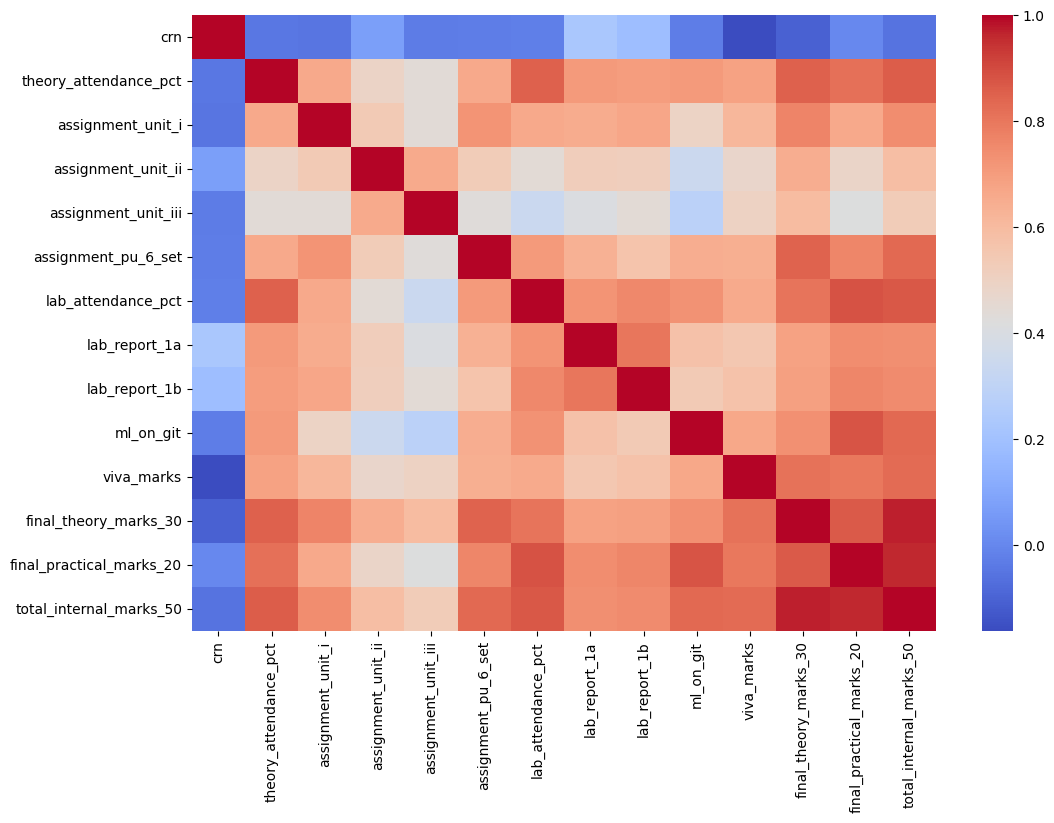

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat2, cmap="coolwarm")
plt.show()

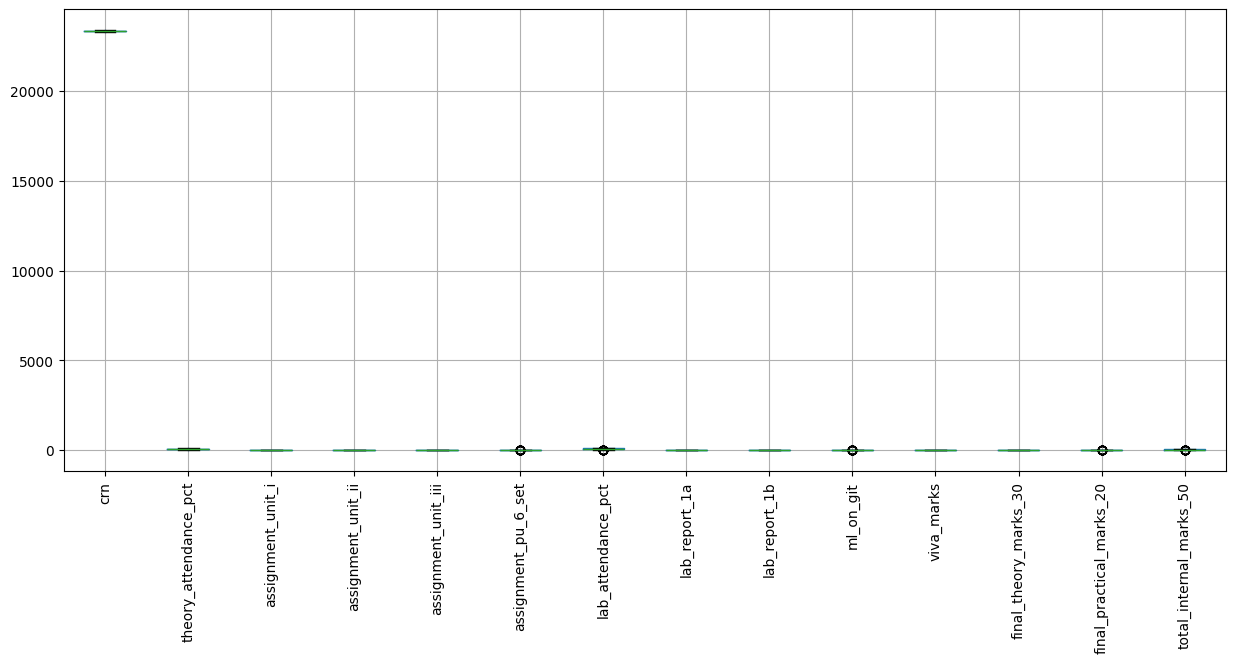

In [32]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

# **5). Model Building**

In [23]:
corr = df.corr(numeric_only=True)

print(corr['total_internal_marks_50'].sort_values(ascending=False))


total_internal_marks_50     1.000000
final_theory_marks_30       0.969016
final_practical_marks_20    0.962881
lab_attendance_pct          0.872387
theory_attendance_pct       0.863205
assignment_pu_6_set         0.833763
ml_on_git                   0.832419
viva_marks                  0.831081
lab_report_1b               0.748589
assignment_unit_i           0.742707
lab_report_1a               0.738189
assignment_unit_ii          0.590173
assignment_unit_iii         0.528287
crn                        -0.056878
Name: total_internal_marks_50, dtype: float64


**Here, the strongest behavioral indicators were Lab_Attendance_Pct, Theory_Attendance_Pct, and Viva_Marks, indicating that attendance and oral performance have the strongest relationship with internal marks.**

In [24]:
#5.1 Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
#5.2 Training model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
#5.3 Predicting
y_pred = model.predict(X_test)
y_pred

array([34.52671705, 32.05344278, 37.49727801, -0.41973146, -0.41973146,
       38.99648696, 36.46408914, 39.92856577, 18.52544221, -0.41973146,
       36.09607384, 40.04817433, 34.63881363, 31.36074302, 41.0887129 ,
       25.33334471, 29.20786494, 33.77226283, 34.96373797, 34.50069378])

**6). Evaluation**

In [27]:


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.075445907757712
MSE: 7.152641359440963
RMSE: 2.6744422520295634
R2 Score: 0.9601317847097395


***Insights:***

The MAE as 2.075 indicates that on average, the model's predictions deviates from the actual values by approx 2.07 units.

The MSE as 7.153 shows the presence of prediction errors.

The RMSE as 2.674 confirms that the typical prediction error is around 2.67 units.

The R2 score as 0.960 indicates that approx 96% of the variance in the dependent variable explained by independent variables,thus suggesting a strong fit.

**7).Model interpretation:**

In [28]:

print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame({
    "Feature": X.columns,

    "Coefficient": model.coef_
})

print(coeff_df)

Intercept: -0.4197314645284891
                 Feature  Coefficient
0  theory_attendance_pct     0.057652
1      assignment_unit_i     0.855398
2     assignment_unit_ii     2.393987
3    assignment_unit_iii     0.799932
4    assignment_pu_6_set     1.546608
5     lab_attendance_pct     0.073563
6          lab_report_1a    -0.513417
7          lab_report_1b     3.116916
8              ml_on_git     2.051790
9             viva_marks     5.160351


**->Actual vs Predicted OUTPUT plot:**

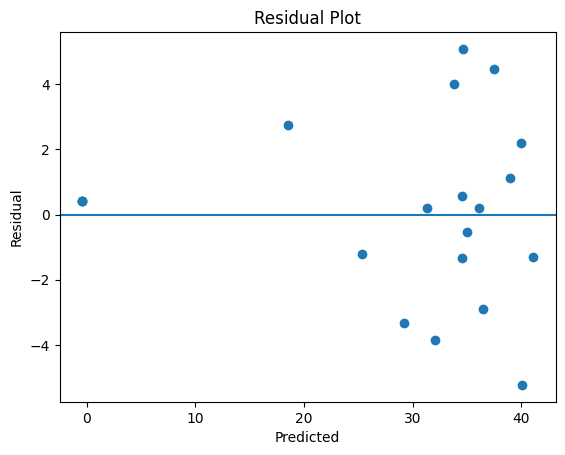

In [29]:

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

# **8). CONCLUSION:**

  Multiple regression model was implemented to model the relationship between a dependent variable(Target variable) and multiple independent variables(Features).

The dataset was first preprocessed and analyzed to ensure correctness of structure and data types. After constructing the feature matrix, regression coefficients were calculated and used to make predictions. The model’s performance was evaluated using residual errors, which helped measure the difference between actual and predicted values.
